In [11]:
import legume

import numpy as np
import matplotlib.pyplot as plt
import time

import autograd.numpy as npa
from autograd import grad, value_and_grad

import legume
from legume.minimize import Minimize

%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# PhC cavity simulation

In [12]:
# Number of PhC periods in x and y directions
Nx, Ny = 16, 10

# Regular PhC parameters
ra = 0.234
dslab = 0.4355
n_slab = 2.21

# Initialize a lattice and PhC
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Make x and y positions in one quadrant of the supercell
# We only initialize one quadrant because we want to shift the holes symmetrically
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

# Move the first two holes to create the L4/3 defect
xp[0] = 2/5
xp[1] = 6/5
nc = len(xp)

# Initialize shift parameters to zeros
dx, dy = np.zeros((nc,)), np.zeros((nc,))

In [13]:
# Define L4/3 PhC cavity with shifted holes
def cavity(dx, dy):
    # Initialize PhC
    phc = legume.PhotCryst(lattice)

    # Add a layer to the PhC
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    # Apply holes symmetrically in the four quadrants
    for ic, x in enumerate(xp):
        yc = yp[ic] if yp[ic] == 0 else yp[ic] + dy[ic]
        xc = x if x == 0 else xp[ic] + dx[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra))
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra))
        if nx-1.6 > xp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra))

    return phc

In [14]:
# Solve for a cavity defined by shifts dx, dy
def gme_cavity(dx, dy, gmax, truncate_g, options):
    # Initialize PhC
    phc = cavity(dx, dy)

    # For speed, we don't want to compute the loss rates of *all* modes that we store
    options['compute_im'] = False

    # Initialize GME
    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)

    # Solve for the real part of the frequencies
    gme.run(kpoints=np.array([[0], [0]]), **options)

    # Find the imaginary frequency of the fundamental cavity mode
    (freq_im, _, _) = gme.compute_rad(0, [Nx*Ny])

    # Finally, compute the quality factor
    Q = gme.freqs[0, Nx*Ny]/2/freq_im[0]
    return (gme, Q)

In [15]:
# Set some GME options
options = {'gmode_inds': [0], 'verbose': True, 'numeig': Nx*Ny+5, 'gradients': 'approx'}

gmax = 2
truncate_g = 'tbt'  # for large rectangular supercells better to use tbt, it is faster and uses less memory

# Run the simulation for the starting cavity (zero shifts as initialized above)
(gme, Q) = gme_cavity(dx, dy, gmax, truncate_g, options)

13.986s total time for real part of frequencies in GuidedModeExp, of which
  0.210s (2%) for guided modes computation using the gmode_compute='exact' method
  0.416s (3%) for inverse matrix of Fourier-space permittivity
  11.698s (84%) for matrix diagionalization using the 'eigh' solver
  1.660s (12%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes


Cavity quality factor: 6454.17


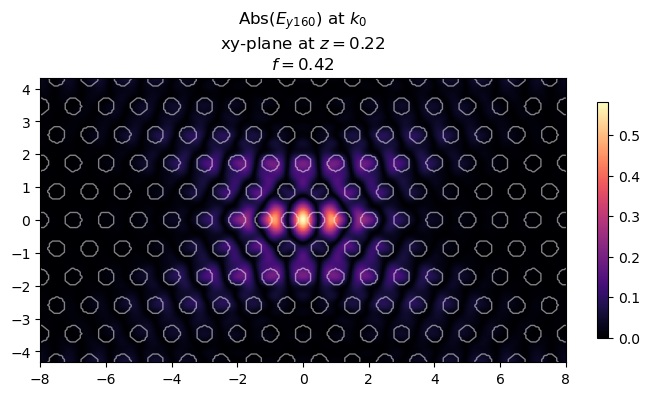

In [16]:

# Print the computed quality factor
print("Cavity quality factor: %1.2f" %Q)

# We can also visualize the cavity and the mode profile of the fundamental mode
ax = legume.viz.field(gme, 'e', 0, Nx*Ny, z=dslab/2, component='y', val='abs', N1=300, N2=200)



## Autograd backend

In [17]:
# To compute gradients, we need to set the `legume` backend to 'autograd'
legume.set_backend('autograd')

# Set GME options
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': Nx*Ny+1, 'gradients': 'approx'}

# Define an objective function which is just the Q of the fundamental mode
def of_Q(params):
    dx = params[0:nc]
    dy = params[nc:]
    (gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)

    # We put a negative sign because we use in-built methods to *minimize* the objective function
    return -Q

## Test gradient of quality factor

In [18]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_Q)

# We do the numerical check w.r.t. the closest hole to the center
ind0 = 0
# We set the starting parameters to zeros, i.e. un-modified cavity
pstart = np.zeros((2*nc, ))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1]
# Print the gradient w.r.t. the parameter index ind0
print("Autograd gradient:  %1.4f, computed in %1.4fs" %(grad_a[ind0], time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_Q(p_test) - of_Q(pstart))/1e-5
print("Numerical gradient: %1.4f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a[ind0] - grad_n)/grad_n))

Autograd gradient:  157506.2934, computed in 21.0943s
Numerical gradient: 157519.7087, computed in 48.8384s
Relative difference: 8.52e-05


## test gradient of fields

In [19]:
# Define an objective function which is proportional to the V of the fundamental mode
def of_V(params):
    dx = params[0:nc]
    dy = params[nc:]
    (gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)

    # Get the electric field in the center of the slab
    Ey = gme.get_field_xy('e', kind=0, mind=Nx*Ny, z=dslab/2, component='y', Nx=3, Ny=3)[0]['y']

    # Notice the use of autograd.numpy (npa) and not plain numpy (np)
    return 1/npa.square(npa.amax(npa.abs(Ey)))

In [20]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_V)

# We do the numerical check w.r.t. the closest hole to the center
ind0 = 0
# We set the starting parameters to zeros, i.e. un-modified cavity
pstart = np.zeros((2*nc, ))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1][ind0]
print("Autograd gradient:  %1.8f, computed in %1.4fs" %(grad_a, time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_V(p_test) - of_V(pstart))/1e-5
print("Numerical gradient: %1.8f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a - grad_n)/grad_n))

/home/jonah/miniconda3/envs/photonics/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  return onp.asarray(out, dtype=A_dtype)


Autograd gradient:  16.42846145, computed in 17.8324s
Numerical gradient: 16.42884011, computed in 23.1803s
Relative difference: 2.30e-05


## Q factor optimization

In [21]:
# Initialize an optimization object
opt = Minimize(of_Q)

# Starting parameters are the un-modified cavity
pstart = np.zeros((2*nc, ))

# Run an 'adam' optimization
(p_opt, ofs) = opt.adam(pstart, step_size=0.005, Nepochs=10, bounds = [-0.25, 0.25])

Epoch:    1/  10 | Duration:  16.67 secs | Objective: -6.454171e+03
Epoch:    2/  10 | Duration:  17.95 secs | Objective: -9.923204e+03
Epoch:    3/  10 | Duration:  20.36 secs | Objective: -1.613968e+04
Epoch:    4/  10 | Duration:  17.42 secs | Objective: -2.634551e+04
Epoch:    5/  10 | Duration:  22.71 secs | Objective: -3.837220e+04
Epoch:    6/  10 | Duration:  23.55 secs | Objective: -6.522058e+04
Epoch:    7/  10 | Duration:  21.21 secs | Objective: -9.175618e+04
Epoch:    8/  10 | Duration:  25.63 secs | Objective: -1.424175e+05
Epoch:    9/  10 | Duration:  23.00 secs | Objective: -2.015266e+05
Epoch:   10/  10 | Duration:  18.76 secs | Objective: -4.609716e+05


Cavity quality factor: 460971.56


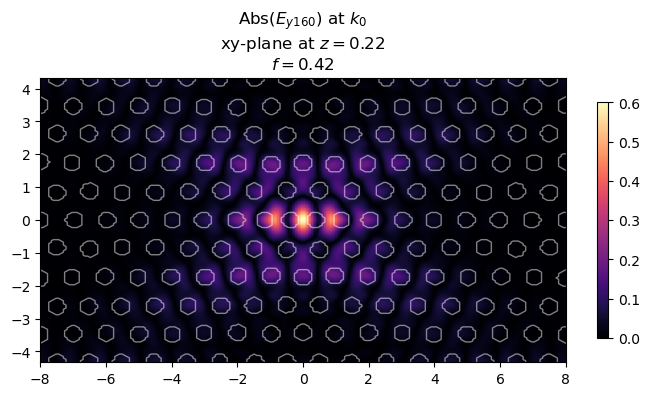

In [22]:
# Optimized parameters
dx = p_opt[0:nc]
dy = p_opt[nc:]

# Run the simulation
(gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)
print("Cavity quality factor: %1.2f" %Q)
ax = legume.viz.field(gme, 'e', 0, Nx*Ny, z=dslab/2, component='y', val='abs', N1=200, N2=200)
